In [1]:
!cp /content/base_data_pipeline.py /content

cp: '/content/base_data_pipeline.py' and '/content/base_data_pipeline.py' are the same file


In [2]:
import base_data_pipeline

In [3]:
train_texts, test_texts, train_labels, test_labels = base_data_pipeline.get_processed_data()

In [4]:
df = base_data_pipeline.load_dataset()

In [5]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import Dataset, DataLoader

In [ ]:
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

In [8]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [9]:
class SMSDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [10]:
train_dataset = SMSDataset(train_encodings, train_labels)
test_dataset = SMSDataset(test_encodings, test_labels)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(torch.cuda.is_available)
print(device)

<function is_available at 0x7ec5f8b44680>
cuda


In [14]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

In [15]:
epoch_losses = []
epoch_acc = []
epoch_f1_scores = []

In [16]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import copy

num_epochs = 10
patience = 2

best_f1 = 0
epochs_no_improve = 0
best_model_state = None

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):

        optimizer.zero_grad()

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1} Training Loss: {avg_loss}")

    # evaluation
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for batch in test_loader:

            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch["labels"].cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, predictions, average="binary"
    )

    print("Accuracy:", accuracy)
    print("F1 Score:", f1)

    epoch_losses.append(avg_loss)
    epoch_acc.append(accuracy)
    epoch_f1_scores.append(f1)

    if f1 > best_f1:

        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0

        print("Improvement detected. Saving model.")

    else:

        epochs_no_improve += 1
        print("No improvement. Patience counter:", epochs_no_improve)

    if epochs_no_improve >= patience:

        print("\nEarly stopping triggered.")
        break


model.load_state_dict(best_model_state)

print("\nBest model restored with F1:", best_f1)

100%|██████████| 279/279 [01:44<00:00,  2.67it/s]



Epoch 1 Training Loss: 0.08102172641893081
Accuracy: 0.9874439461883409
F1 Score: 0.9533333333333334
Improvement detected. Saving model.


100%|██████████| 279/279 [01:50<00:00,  2.52it/s]



Epoch 2 Training Loss: 0.0745484906396458
Accuracy: 0.9704035874439462
F1 Score: 0.8754716981132076
No improvement. Patience counter: 1


100%|██████████| 279/279 [01:50<00:00,  2.52it/s]



Epoch 3 Training Loss: 0.10702661895794013
Accuracy: 0.9847533632286996
F1 Score: 0.9407665505226481
No improvement. Patience counter: 2

Early stopping triggered.

Best model restored with F1: 0.9533333333333334


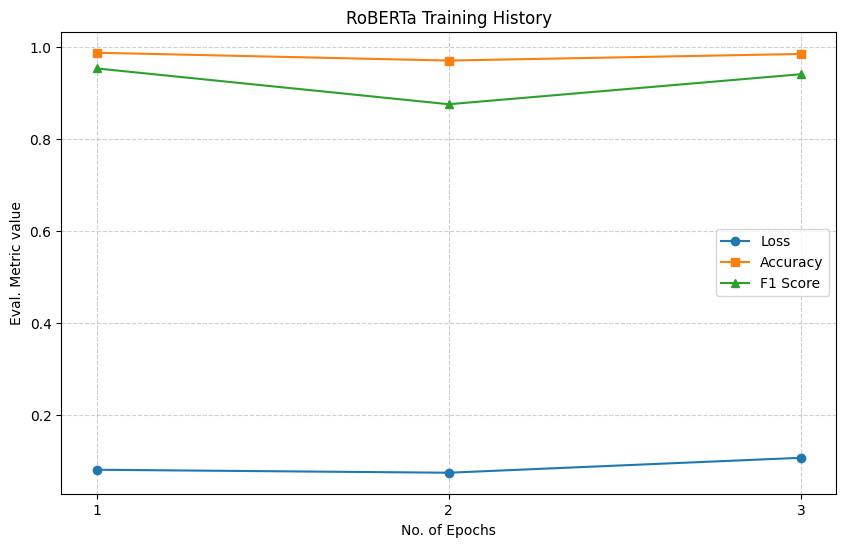

In [17]:
import matplotlib.pyplot as plt

def plt_train_his(losses, acc, f1, model="Model"):
  epochs = range(1, len(losses) + 1)

  plt.figure(figsize=(10, 6))

  plt.plot(epochs, losses, marker='o', label="Loss")
  plt.plot(epochs, acc, marker='s', label="Accuracy")
  plt.plot(epochs, f1, marker='^', label="F1 Score")

  plt.xlabel("No. of Epochs")
  plt.ylabel("Eval. Metric value")
  plt.title(f"{model} Training History")
  plt.xticks(epochs)
  plt.grid(True, linestyle="--", alpha=0.6)
  plt.legend()
  plt.show()

plt_train_his(
    epoch_losses,
    epoch_acc,
    epoch_f1_scores,
    model="RoBERTa"
)

In [18]:
!cp /content/evaluation_utils.py /content

cp: '/content/evaluation_utils.py' and '/content/evaluation_utils.py' are the same file


In [19]:
import evaluation_utils

In [20]:
results = evaluation_utils.evaluate_model(true_labels, predictions)

In [21]:
print("Accuracy :", results["Accuracy"])
print("Precision :", results["Precision"])
print("Recall :",  results["Recall"])
print("F1 Score :",  results["F1 Score"])
print("Confusion Matrix :")
print(results["Confusion Matrix"])
print("Classification Matrix")
print(results["Classification Report"])

Accuracy : 0.9847533632286996
Precision : 0.9782608695652174
Recall : 0.9060402684563759
F1 Score : 0.9407665505226481
Confusion Matrix :
[[963   3]
 [ 14 135]]
Classification Matrix
              precision    recall  f1-score   support

           0     0.9857    0.9969    0.9913       966
           1     0.9783    0.9060    0.9408       149

    accuracy                         0.9848      1115
   macro avg     0.9820    0.9515    0.9660      1115
weighted avg     0.9847    0.9848    0.9845      1115



In [22]:
from torch.nn.functional import softmax

model.eval()

predictions = []
true_labels = []
probabilities = []


In [23]:
with torch.no_grad():
  for batch in test_loader:
    batch = {k: v.to(device) for k, v in batch.items()}

    op = model(**batch)
    log = op.logits

    probs = softmax(log, dim=1)

    preds = torch.argmax(logits, dim=1)

    probabilities.extend(probs[:, 1].cpu().numpy())
    predictions.extend(preds.cpu().numpy())
    true_labels.extend(batch["labels"].cpu().numpy())

In [24]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(true_labels, probabilities)

print(roc_auc)

0.9975544346714467


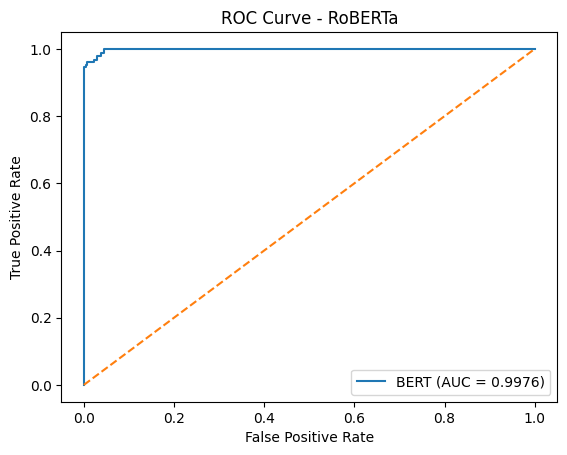

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(true_labels, probabilities)

plt.figure()
plt.plot(fpr, tpr, label=f"BERT (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RoBERTa")
plt.legend()
plt.show()